In [1]:
%matplotlib inline  
import cv2 as cv
import time
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
# leer primer imagen
def read_image(image_name):
   # image_path = os.path.join("white_patch", image_name)
    img = cv.imread(image_name, cv.IMREAD_COLOR)
    if img is None:
            print("Image not found.")
    return(img)    


In [26]:
# Convertir a float para evitar saturación durante los cálculos
def white_patch (img):
    image = img.astype(np.float32)
    
    # Máximo de cada canal (OpenCV usa BGR)
    max_b = np.max(image[:, :, 0])
    max_g = np.max(image[:, :, 1])
    max_r = np.max(image[:, :, 2])
    
    # Factores de escala
    image[:, :, 0] *= 255.0 / max_b
    image[:, :, 1] *= 255.0 / max_g
    image[:, :, 2] *= 255.0 / max_r
    
    fact_b=round((255/max_b),2)
    fact_g=round((255/max_g),2)
    fact_r=round((255/max_r),2)

    # Limitar valores al rango [0,255]
    image = np.clip(image, 0, 255).astype(np.uint8)

    imgRGB_orig = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    imgRGB_wp = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    plt.imshow(imgRGB_orig)
    plt.title(f'Imagen Original {max_b} {max_g} {max_r}')
    plt.show()
    plt.imshow(imgRGB_wp)
    plt.title(f'Imagen corregida con White Patch {format(fact_b, ".2f")} {format(fact_g, ".2f")} {format(fact_r, ".2f")}')
    plt.show()

    return()

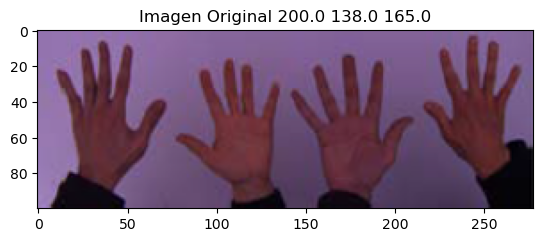

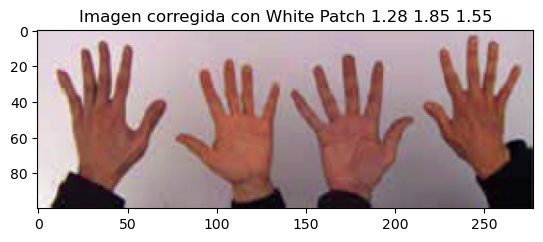

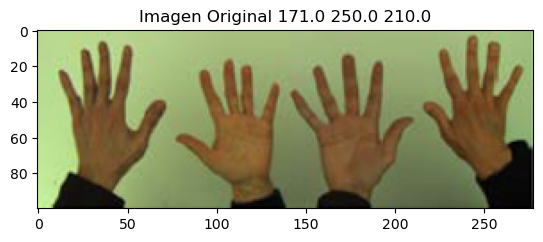

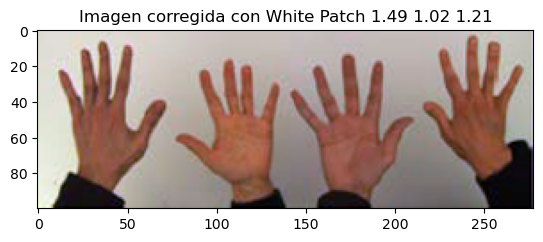

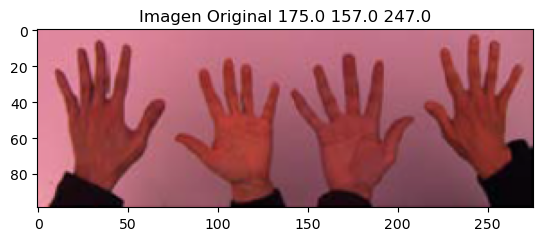

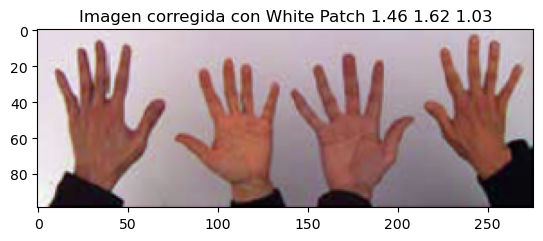

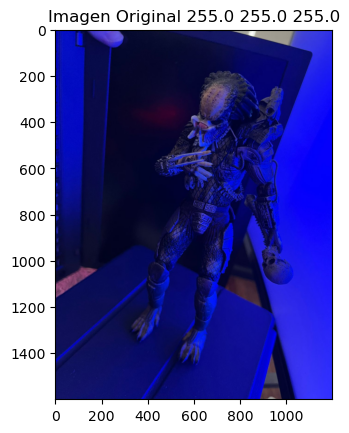

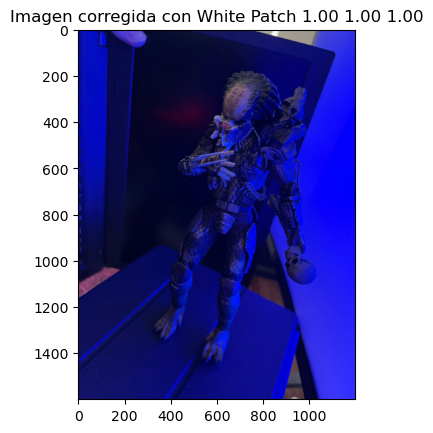

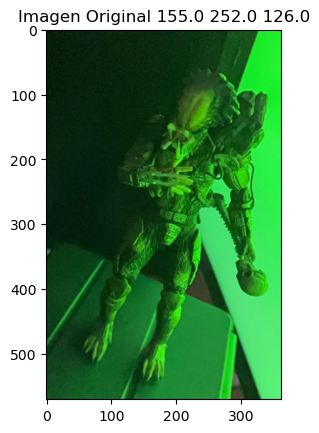

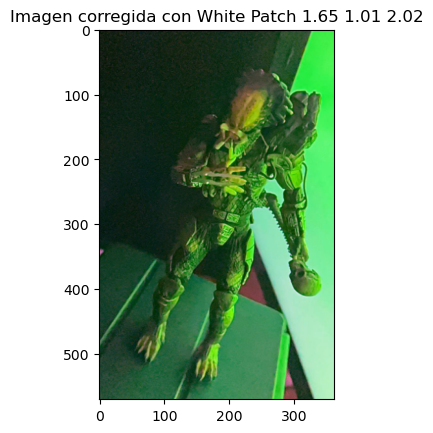

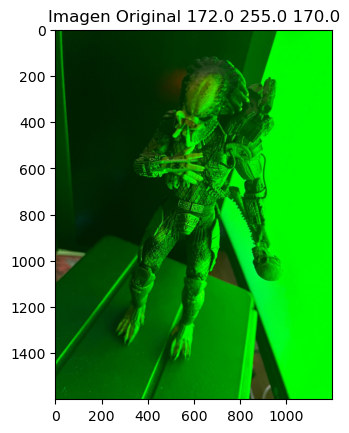

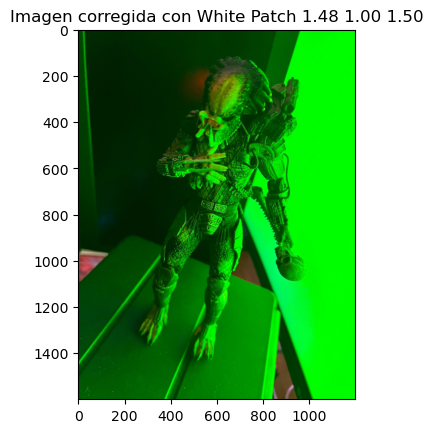

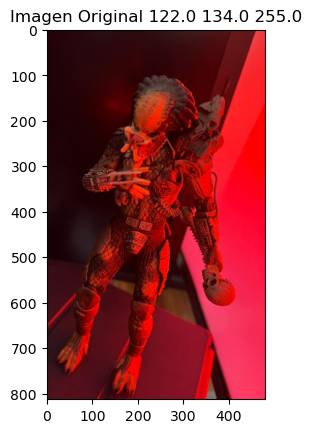

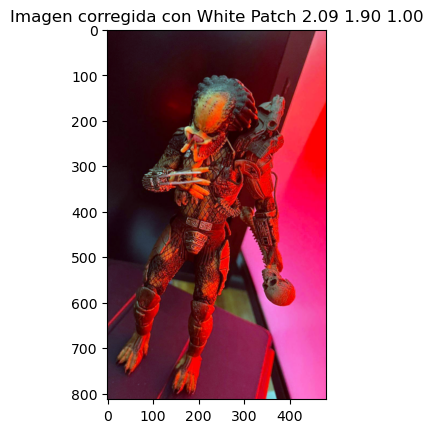

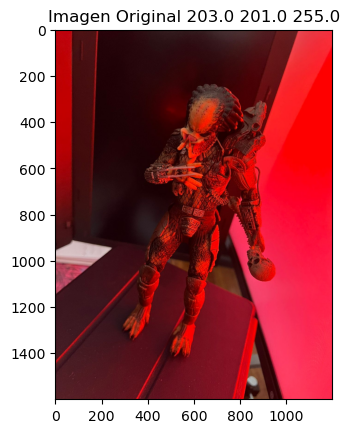

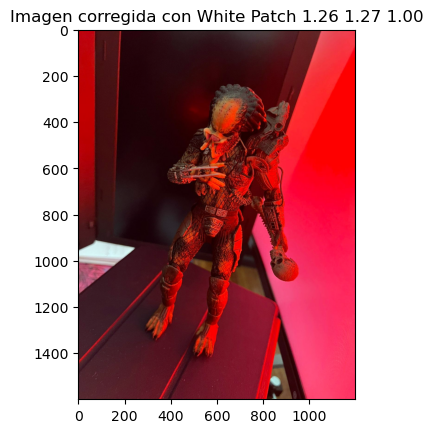

In [27]:
folder = Path("white_patch")
for image_path in folder.iterdir():
    white_patch(read_image(image_path))